Importing required librabries and file needed for the project.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Importing Excel file
df = pd.read_excel('retail_sales_dataset.xlsx', engine='openpyxl')

Checking the first few rows

In [36]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


Checking the shape of the dataset

In [37]:
df.shape

(1000, 9)

Checking all datatypes to see if accurate

In [38]:
df.dtypes

Transaction ID               int64
Date                datetime64[us]
Customer ID                    str
Gender                         str
Age                          int64
Product Category               str
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

Checking for missing values

In [39]:
df.isna()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
995,False,False,False,False,False,False,False,False,False
996,False,False,False,False,False,False,False,False,False
997,False,False,False,False,False,False,False,False,False
998,False,False,False,False,False,False,False,False,False


Checking duplicates

In [40]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

Checking for impossible or suspicious data

In [41]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [42]:
df["Gender"].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

Verifying the datatype of the 'Date' column

In [43]:
df["Date"].dtypes

dtype('<M8[us]')

Checking for inconsistencies

In [44]:
df["Total Amount"] != df["Price per Unit"] * df["Quantity"]

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

Plotting The Graph For Monthly Revenue

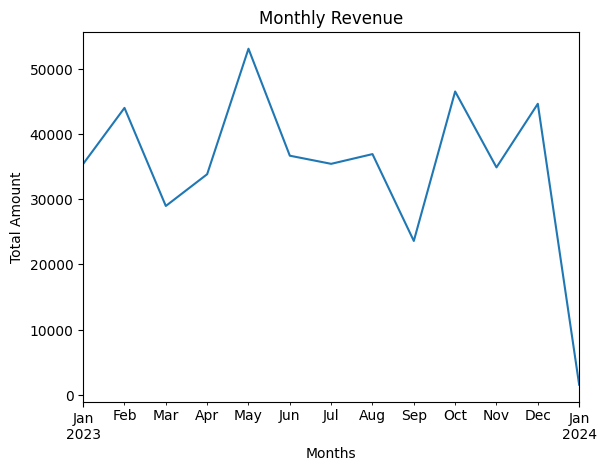

In [45]:
df["Month"] = df["Date"].dt.to_period("M")
monthly_revenue = df.groupby("Month")["Total Amount"].sum()

monthly_revenue.plot(kind="line")

plt.title("Monthly Revenue")
plt.xlabel("Months")
plt.ylabel("Total Amount")

plt.show()

Plotting The Graph For Revenue By Product Category

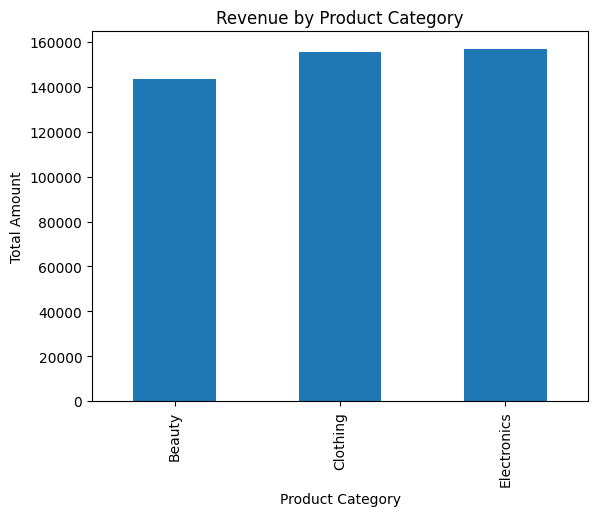

In [46]:
revenue_by_product_category = df.groupby("Product Category")["Total Amount"].sum()

revenue_by_product_category.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Amount")

plt.show()

Plotting The Graph For Revenue By Gender

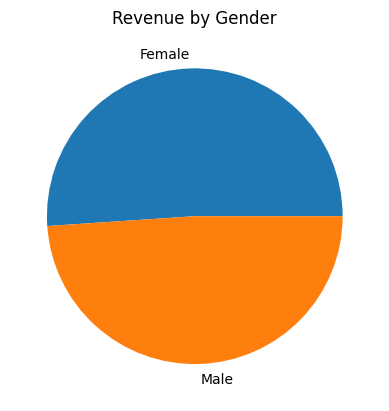

In [47]:
revenue_by_gender = df.groupby("Gender")["Total Amount"].sum()

revenue_by_gender.plot(kind="pie")

plt.title("Revenue by Gender")

plt.show()

Plotting The Graph For Top 10 Customers By Spending

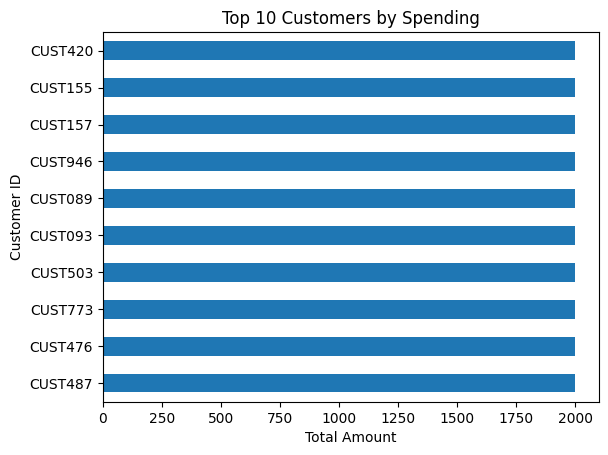

In [48]:
top_10_customers = (
    df.groupby("Customer ID")["Total Amount"].sum()
    .sort_values(ascending=False)
    .head(10)
)

top_10_customers.plot(kind="barh")

plt.title("Top 10 Customers by Spending")
plt.xlabel("Total Amount")
plt.ylabel("Customer ID")

plt.show()

Plotting The Graph For Average Spending By Age Group

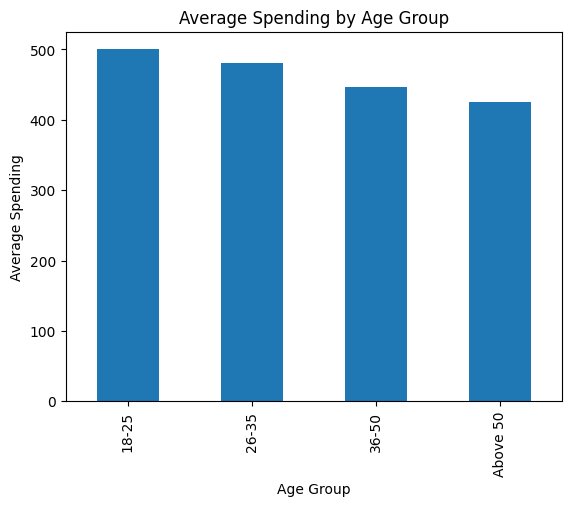

In [49]:
df["Age Group"] = pd.cut(
    df["Age"],
    bins=[0,17,25,35,50,100],
    labels=["Under 18","18-25","26-35","36-50","Above 50"]
)

avg_spending = (
    df.groupby("Age Group")["Total Amount"].mean()
)

avg_spending.plot(kind="bar")

plt.title("Average Spending by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Spending")

plt.show()

Exporting cleaned dataset

In [50]:
df.to_excel('retail_sales_dataset_cleaned.xlsx', index=False)